<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [3]:
# Check for GPU
!nvidia-smi

Fri Dec 19 14:16:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro T2000                 WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   51C    P8              4W /   60W |      41MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


2.5.1+cu121


In [4]:
import torch
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from tqdm import tqdm


## 1. What are 3 areas in industry where computer vision is currently being used?

- Used in medical imaging and patient monitoring.
- Used for quality control and safety in factories.
- A core technology behind autonomous and smart transportation systems.

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

- **Overfitting** occurs when a machine learning model learns the `training data` too closely, including its noise and specific details, so it performs very well on that data but **fails to generalize** and make accurate predictions on new, unseen data.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

1. `Regularization` : Techniques like L1 and L2 regularization add a penalty to the model’s loss function that discourages it from becoming too complex, which helps the model generalize better to new data.
2. `Cross-Validation` : K-fold cross-validation splits your data into several parts and trains the model on different combinations of them, helping ensure that the model performs well on unseen data rather than just on the training set.
3. `Early Stopping` : Early stopping monitors the model’s performance on a validation set during training and stops training when the validation performance stops improving, preventing the model from over-learning noise in the training data.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [15]:
train_data = datasets.MNIST(root='./data',
                            train=True,
                            download=True,
                            transform=transforms.ToTensor())
test_data = datasets.MNIST(root='./data',
                           train=False,
                           download=True,
                           transform=transforms.ToTensor())

## 6. Visualize at least 5 different samples of the MNIST training dataset.

In [17]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [19]:
image, label = train_data[0]
print(f"Image type: {type(image)}")  
print(f"Label: {label}")

Image type: <class 'torch.Tensor'>
Label: 5


Tensor shape: torch.Size([1, 28, 28])


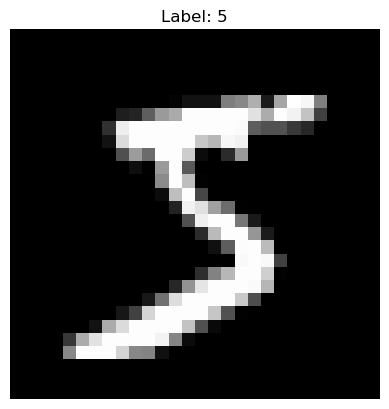

In [23]:
img_tensor, label = train_data[0]
print(f"Tensor shape: {img_tensor.shape}")


img_np = img_tensor.squeeze().numpy()  
plt.imshow(img_np, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

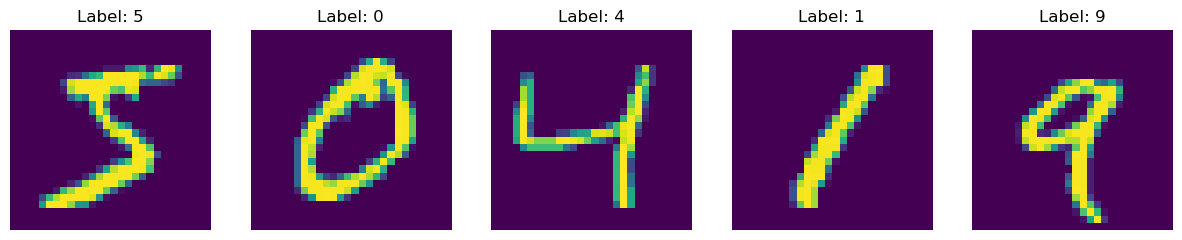

In [29]:
plt.figure(figsize=(15, 3))  

for i in range(5):
    img_tensor, label = train_data[i]
    img_np = img_tensor.squeeze().numpy()
    
    plt.subplot(1, 5, i+1) 
    plt.imshow(img_np) # cmap='gray' to appear as the image in previous cell "balck & white"
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.show()

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [30]:
BATCH_SIZE = 32
train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001EE6028BA70>, <torch.utils.data.dataloader.DataLoader object at 0x000001EE61E8EDE0>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [31]:
class TinyVGG(nn.Module):
    """
    Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [33]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [34]:
import time

def train(model,
          train_dataloader,
          test_dataloader,
          optimizer,
          loss_fn,
          accuracy_fn,
          epochs,
          device):

    start_time = time.time()

    for epoch in range(epochs):
        print(f"Epoch: {epoch+1}/{epochs}")
        train_step(model=model,
                   data_loader=train_dataloader,
                   loss_fn=loss_fn,
                   optimizer=optimizer,
                   accuracy_fn=accuracy_fn,
                   device=device)

        test_step(data_loader=test_dataloader,
                  model=model,
                  loss_fn=loss_fn,
                  accuracy_fn=accuracy_fn,
                  device=device)

    end_time = time.time()
    total_time = end_time - start_time
    print(f"Total training time on {device}: {total_time:.2f} seconds")

    return total_time


In [35]:

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


In [36]:
cpu_device = torch.device("cpu")

model_cpu = TinyVGG(
    input_shape=1,
    hidden_units=10,
    output_shape=10
).to(cpu_device)

optimizer_cpu = optim.Adam(model_cpu.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

cpu_time = train(model=model_cpu,
                 train_dataloader=train_dataloader,
                 test_dataloader=test_dataloader,
                 optimizer=optimizer_cpu,
                 loss_fn=loss_fn,
                 accuracy_fn=accuracy_fn,
                 epochs=5,
                 device=cpu_device)

Epoch: 1/5
Train loss: 0.25876 | Train accuracy: 91.59%
Test loss: 0.11567 | Test accuracy: 96.60%

Epoch: 2/5
Train loss: 0.08879 | Train accuracy: 97.30%
Test loss: 0.07176 | Test accuracy: 97.82%

Epoch: 3/5
Train loss: 0.06576 | Train accuracy: 97.96%
Test loss: 0.05986 | Test accuracy: 98.11%

Epoch: 4/5
Train loss: 0.05493 | Train accuracy: 98.31%
Test loss: 0.05089 | Test accuracy: 98.38%

Epoch: 5/5
Train loss: 0.04755 | Train accuracy: 98.53%
Test loss: 0.05433 | Test accuracy: 98.35%

Total training time on cpu: 113.37 seconds


In [37]:
gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_gpu = TinyVGG(
    input_shape=1,
    hidden_units=10,
    output_shape=10
).to(gpu_device)

optimizer_gpu = optim.Adam(model_gpu.parameters(), lr=0.001)

gpu_time = train(model=model_gpu,
                 train_dataloader=train_dataloader,
                 test_dataloader=test_dataloader,
                 optimizer=optimizer_gpu,
                 loss_fn=loss_fn,
                 accuracy_fn=accuracy_fn,
                 epochs=5,
                 device=gpu_device)


Epoch: 1/5
Train loss: 0.23669 | Train accuracy: 92.47%
Test loss: 0.08093 | Test accuracy: 97.37%

Epoch: 2/5
Train loss: 0.07138 | Train accuracy: 97.83%
Test loss: 0.06233 | Test accuracy: 98.01%

Epoch: 3/5
Train loss: 0.05615 | Train accuracy: 98.29%
Test loss: 0.04741 | Test accuracy: 98.53%

Epoch: 4/5
Train loss: 0.04677 | Train accuracy: 98.53%
Test loss: 0.03946 | Test accuracy: 98.59%

Epoch: 5/5
Train loss: 0.03963 | Train accuracy: 98.74%
Test loss: 0.04250 | Test accuracy: 98.56%

Total training time on cuda: 72.92 seconds


In [38]:
print(f"CPU training time: {cpu_time:.2f} seconds")
print(f"GPU training time: {gpu_time:.2f} seconds")


CPU training time: 113.37 seconds
GPU training time: 72.92 seconds


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [39]:
def visualize_predictions(model, data_loader, device, num_images=5):
    model.eval()
    model.to(device)

    images, labels, preds = [], [], []

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            predicted_labels = y_pred.argmax(dim=1)

            images.extend(X.cpu())
            labels.extend(y.cpu())
            preds.extend(predicted_labels.cpu())

            if len(images) >= num_images:
                break

    plt.figure(figsize=(15, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        img = images[i].squeeze().numpy()
        plt.imshow(img, cmap='gray')
        plt.title(f"Pred: {preds[i]}\nTrue: {labels[i]}")
        plt.axis('off')
    plt.show()


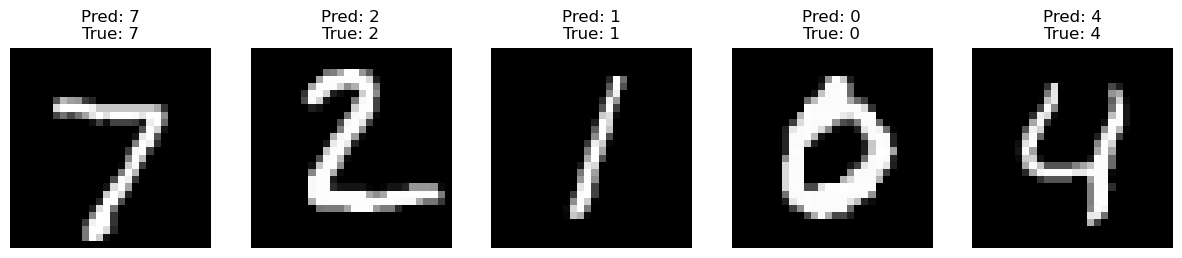

In [40]:
visualize_predictions(model_gpu, test_dataloader, device=gpu_device, num_images=5)


## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, data_loader, device):
    model.eval()
    model.to(device)

    all_labels = []
    all_preds = []

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            predicted_labels = y_pred.argmax(dim=1)

            all_labels.extend(y.cpu().numpy())      
            all_preds.extend(predicted_labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=plt.gca())
    plt.show()


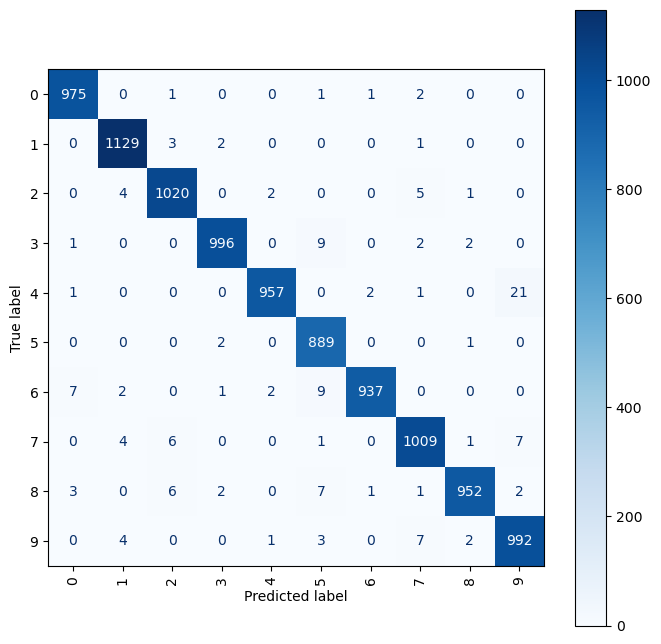

In [42]:
plot_confusion_matrix(model_gpu, test_dataloader, device=gpu_device)


## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [43]:
x = torch.randn(1, 3, 64, 64)

In [44]:
conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3)
out1 = conv1(x)
print(f"Input shape: {x.shape}")
print(f"Output shape with kernel_size=3: {out1.shape}") 
#((n - f + 2p) / s ) +1  = (( 64 - 3 + 2*0 )/1) + 1 = 62
 

Input shape: torch.Size([1, 3, 64, 64])
Output shape with kernel_size=3: torch.Size([1, 6, 62, 62])


In [46]:
conv2 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5) 
out2 = conv2(x)
print(f"Input shape: {x.shape}")
print(f"Output shape with kernel_size=5: {out2.shape}")


Input shape: torch.Size([1, 3, 64, 64])
Output shape with kernel_size=5: torch.Size([1, 6, 60, 60])


In [47]:
conv3 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=7)  
out3 = conv3(x)
print(f"Input shape: {x.shape}")
print(f"Output shape with kernel_size=7: {out3.shape}")


Input shape: torch.Size([1, 3, 64, 64])
Output shape with kernel_size=7: torch.Size([1, 6, 58, 58])


- As the`kernel_size` **increases**, the height and width of the output tensor **decrease**, because a larger filter covers more area of the input.
- If we use `padding`, we can control it so that the spatial dimensions remain the same regardless of the kernel size.

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [51]:
transform = transforms.ToTensor()

train_data = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|████████████████████████████████████████████| 26.4M/26.4M [00:17<00:00, 1.54MB/s]


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|█████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 351kB/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|████████████████████████████████████████████| 4.42M/4.42M [00:02<00:00, 1.62MB/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 5.17MB/s]


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



In [53]:
train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001EE1BF2D400>, <torch.utils.data.dataloader.DataLoader object at 0x000001EE1C0B9AC0>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [56]:


class FashionMNISTModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, 
                      stride=1, 
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) 
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x



In [58]:
model_2 = FashionMNISTModelV2(input_shape=1, 
    hidden_units=10, 
    output_shape=len(class_names)).to(device)

In [59]:

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_2.parameters(), lr=0.001)
torch.manual_seed(42)


train(model=model_2,
                 train_dataloader=train_dataloader,
                 test_dataloader=test_dataloader,
      
                 optimizer=optimizer,
                 loss_fn=loss_fn,
                 accuracy_fn=accuracy_fn,
                 epochs=5,
                 device=device)

Epoch: 1/5
Train loss: 0.53249 | Train accuracy: 80.79%
Test loss: 0.38504 | Test accuracy: 86.58%

Epoch: 2/5
Train loss: 0.35239 | Train accuracy: 87.39%
Test loss: 0.34622 | Test accuracy: 87.22%

Epoch: 3/5
Train loss: 0.31467 | Train accuracy: 88.70%
Test loss: 0.33158 | Test accuracy: 87.93%

Epoch: 4/5
Train loss: 0.29192 | Train accuracy: 89.44%
Test loss: 0.30009 | Test accuracy: 89.29%

Epoch: 5/5
Train loss: 0.27537 | Train accuracy: 90.01%
Test loss: 0.29913 | Test accuracy: 89.24%

Total training time on cuda: 214.03 seconds


214.03446245193481

In [65]:
def count_wrong_predictions(model, data_loader, device):
    model.eval()
    model.to(device)

    total_wrong = 0

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            predicted = y_pred.argmax(dim=1)

            total_wrong += (predicted != y).sum().item()

    return total_wrong

num_wrong = count_wrong_predictions(model_2, test_dataloader, device)
print(f"Number of wrong predictions: {num_wrong}")
print(f"Total test samples: {len(test_data)}")
print(f"Accuracy: {(1 - num_wrong/len(test_data))*100:.2f}%")


Number of wrong predictions: 1078
Total test samples: 10000
Accuracy: 89.22%


In [60]:

class_names = test_data.classes 

def visualize_wrong_predictions(model, data_loader, device, num_images=5):
    model.eval()
    model.to(device)
    
    wrong_images = []
    true_labels = []
    pred_labels = []

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            predicted = y_pred.argmax(dim=1)

            mask = predicted != y
            wrong_images.extend(X[mask].cpu())
            true_labels.extend(y[mask].cpu())
            pred_labels.extend(predicted[mask].cpu())

            if len(wrong_images) >= num_images:
                break

    plt.figure(figsize=(15, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        img = wrong_images[i].squeeze().numpy()
        plt.imshow(img, cmap='gray')
        plt.title(f"Pred: {class_names[pred_labels[i]]}\nTrue: {class_names[true_labels[i]]}")
        plt.axis('off')
    plt.show()


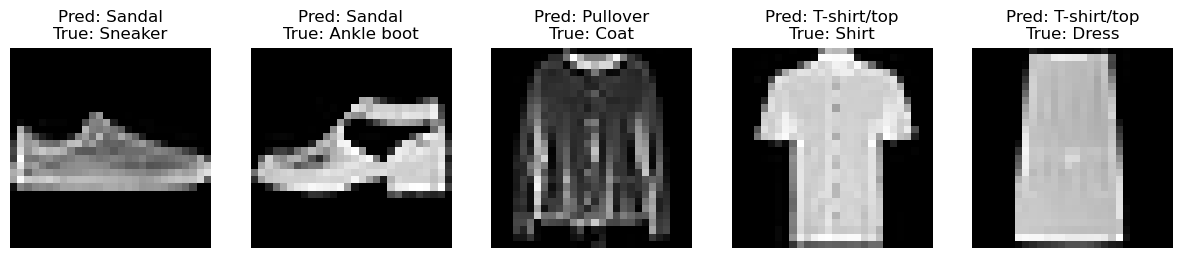

In [64]:
visualize_wrong_predictions(model_2, test_dataloader, device, num_images=5)


- **Some mistakes** seem understandable because certain classes in FashionMNIST are visually very similar:
   - `Example`:
      - "T-shirt/top" vs "Shirt" — it’s difficult even for humans to distinguish sometimes.
      - "Sandal" vs "Sneaker" or "Ankle boot" — these footwear items can look very alike in low-resolution 28x28 images.

- **Other mistakes**, like "Pullover" predicted as "Coat", also reflect ambiguous boundaries between clothing categories in the dataset.

# DONE

### *Thank you for all your effort and support eng.Mohamed , wish u all the best!*